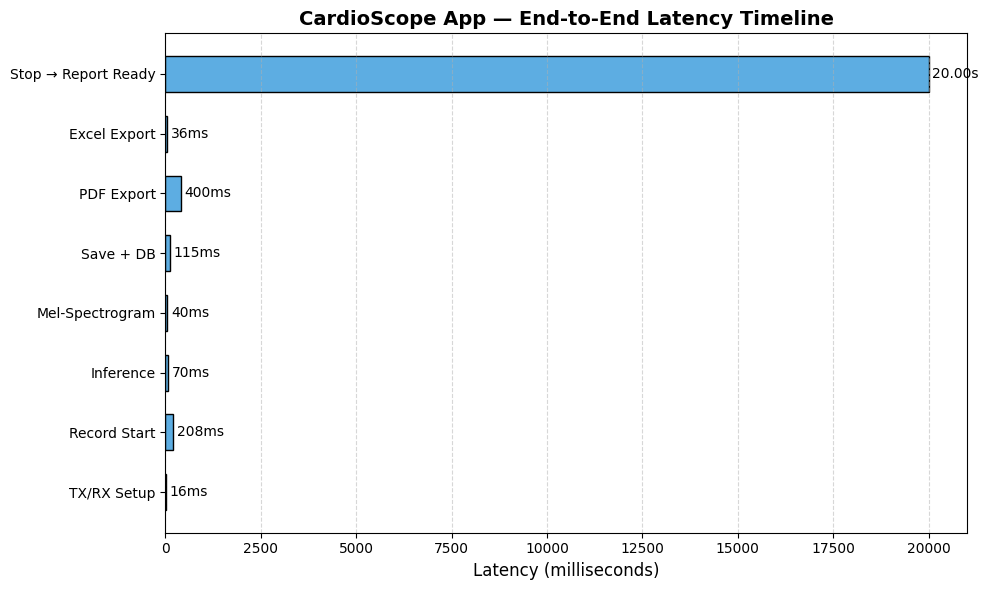

In [4]:
import matplotlib.pyplot as plt

# Data (based on your logs)
stages = [
    "TX/RX Setup",
    "Record Start",
    "Inference",
    "Mel-Spectrogram",
    "Save + DB",
    "PDF Export",
    "Excel Export",
    "Stop → Report Ready"
]
latencies = [16, 208, 70, 40, 115, 400, 36, 20000]

# Chart setup
plt.figure(figsize=(10, 6))
bars = plt.barh(stages, latencies, height=0.6, color="#5DADE2", edgecolor="black")

plt.title("CardioScope App — End-to-End Latency Timeline", fontsize=14, weight="bold")
plt.xlabel("Latency (milliseconds)", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.5)

# Annotate each bar
for bar, latency in zip(bars, latencies):
    label = f"{latency/1000:.2f}s" if latency > 1000 else f"{latency}ms"
    plt.text(latency + 100, bar.get_y() + bar.get_height()/2,
             label, va="center", fontsize=10, color="black")

plt.tight_layout()
plt.savefig("CardioScope_Latency_Timeline.png", dpi=300)
plt.show()


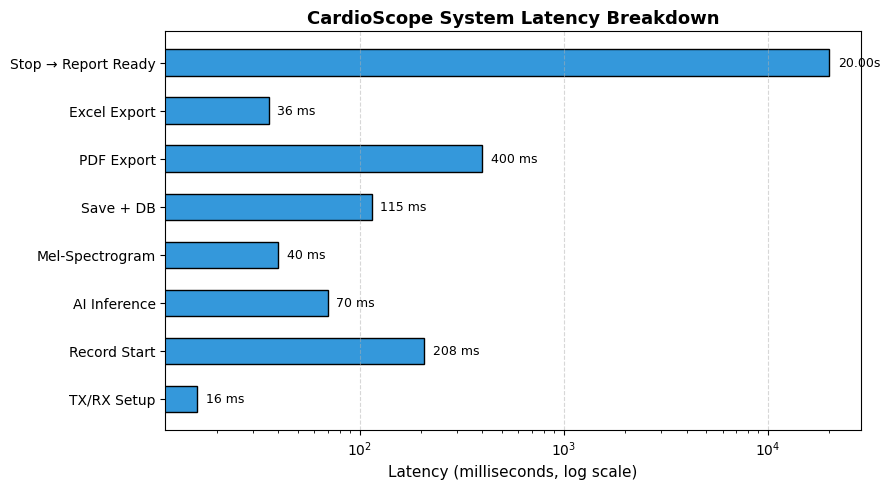

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data from latency logs ---
stages = [
    "TX/RX Setup",
    "Record Start",
    "AI Inference",
    "Mel-Spectrogram",
    "Save + DB",
    "PDF Export",
    "Excel Export",
    "Stop → Report Ready"
]
latencies_ms = np.array([16, 208, 70, 40, 115, 400, 36, 20000])

# --- Plot setup ---
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    stages, latencies_ms,
    color="#3498DB", edgecolor="black", height=0.55
)

# --- Axis formatting ---
ax.set_xscale("log")  # Log scale to show both ms and seconds cleanly
ax.set_xlabel("Latency (milliseconds, log scale)", fontsize=11)
ax.set_title("CardioScope System Latency Breakdown", fontsize=13, weight="bold")
ax.grid(axis="x", linestyle="--", alpha=0.5)

# --- Annotate bars ---
for bar, latency in zip(bars, latencies_ms):
    label = f"{latency/1000:.2f}s" if latency > 1000 else f"{latency:.0f} ms"
    ax.text(latency * 1.1, bar.get_y() + bar.get_height()/2,
            label, va="center", fontsize=9)

# --- Styling ---
plt.tight_layout()
plt.savefig("CardioScope_Latency_Breakdown.png", dpi=400, bbox_inches="tight")
plt.show()


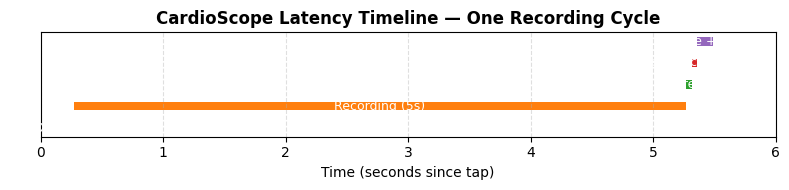

In [8]:
import matplotlib.pyplot as plt

phases = [
    "TX/RX Init",
    "Recording (5s)",
    "Inference",
    "Mel-Spectrogram",
    "Save + DB",
]
start_times = [0, 0.27, 5.27, 5.32, 5.36]  # seconds since user tap
durations = [0.003, 5.0, 0.045, 0.035, 0.13]

plt.figure(figsize=(8, 2))
for i, (phase, start, dur) in enumerate(zip(phases, start_times, durations)):
    plt.barh(y=i, width=dur, left=start, height=0.4, label=phase)
    plt.text(start + dur/2, i, phase, ha='center', va='center', fontsize=9, color='white')

plt.xlabel("Time (seconds since tap)")
plt.title("CardioScope Latency Timeline — One Recording Cycle", fontsize=12, weight='bold')
plt.xlim(0, 6)
plt.yticks([])
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


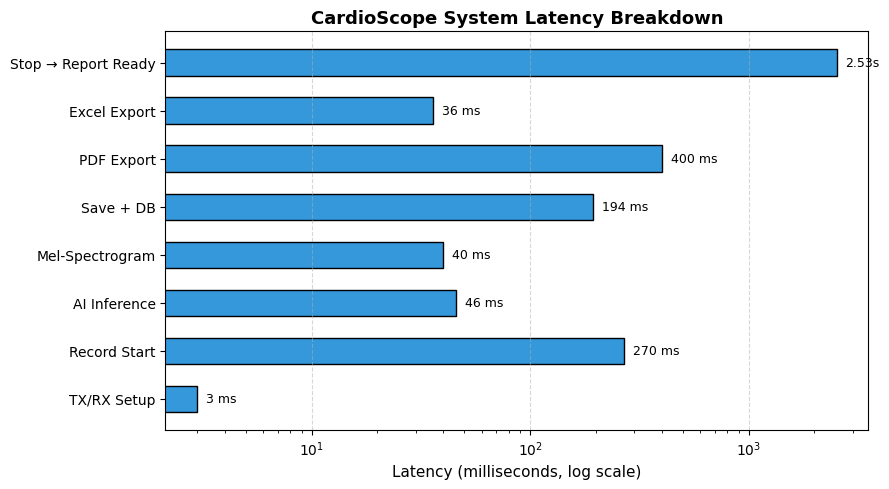

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# === CardioScope Latency Breakdown (ms) ===
stages = [
    "TX/RX Setup",
    "Record Start",
    "AI Inference",
    "Mel-Spectrogram",
    "Save + DB",
    "PDF Export",
    "Excel Export",
    "Stop → Report Ready"
]

# Mean latencies (from your logs)
latencies_ms = np.array([3, 270, 46, 40, 194, 400, 36, 2529])

# --- Plot setup ---
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(stages, latencies_ms, color="#3498DB", edgecolor="black", height=0.55)

# --- Axis formatting ---
ax.set_xscale("log")
ax.set_xlabel("Latency (milliseconds, log scale)", fontsize=11)
ax.set_title("CardioScope System Latency Breakdown", fontsize=13, weight="bold")
ax.grid(axis="x", linestyle="--", alpha=0.5)

# --- Annotate bars ---
for bar, latency in zip(bars, latencies_ms):
    label = f"{latency/1000:.2f}s" if latency > 1000 else f"{latency:.0f} ms"
    ax.text(latency * 1.1, bar.get_y() + bar.get_height()/2,
            label, va="center", fontsize=9)

# --- Styling ---
plt.tight_layout()
plt.savefig("CardioScope_Latency_Breakdown.png", dpi=400, bbox_inches="tight")
plt.show()

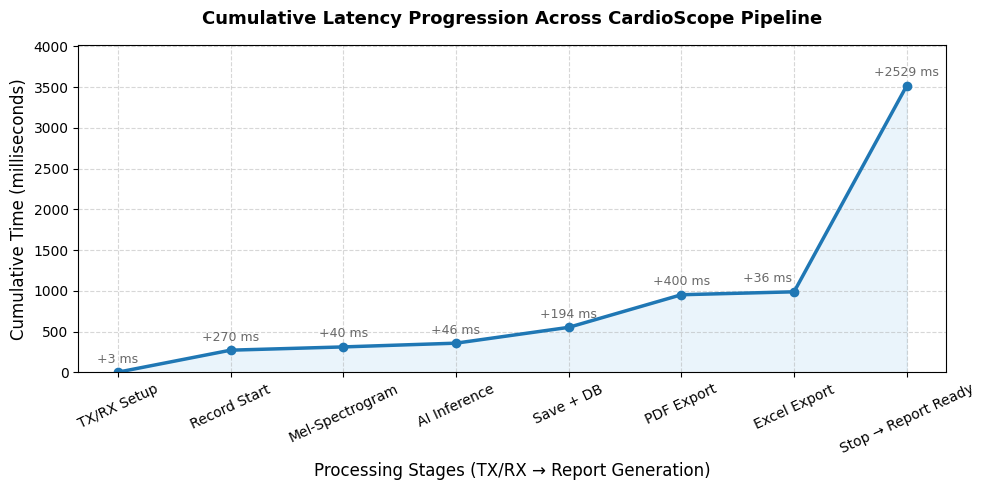

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# --- CardioScope Latency Data ---
stages = [
    "TX/RX Setup", "Record Start", "Mel-Spectrogram",
    "AI Inference", "Save + DB", "PDF Export",
    "Excel Export", "Stop → Report Ready"
]
latencies_ms = np.array([3, 270, 40, 46, 194, 400, 36, 2529])
cumulative = np.cumsum(latencies_ms)

# --- Plot ---
plt.figure(figsize=(10, 5))
plt.plot(stages, cumulative, color="#1F77B4", linewidth=2.5, marker="o")
plt.fill_between(stages, cumulative, alpha=0.25, color="#AED6F1")

# --- Add per-stage text labels (in ms) ---
for i, (x, y, latency) in enumerate(zip(stages, cumulative, latencies_ms)):
    label = f"+{latency:.0f} ms"
    if x == "Excel Export":
        # Move slightly left to avoid overlapping the line
        plt.text(i - 0.24, y + 80, label, ha='center', va='bottom', fontsize=9, color='dimgray')
    else:
        plt.text(i, y + 80, label, ha='center', va='bottom', fontsize=9, color='dimgray')

# --- Titles and Axes ---
plt.title("Cumulative Latency Progression Across CardioScope Pipeline", fontsize=13, weight="bold", pad=15)
plt.xlabel("Processing Stages (TX/RX → Report Generation)", fontsize=12)
plt.ylabel("Cumulative Time (milliseconds)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=25)

# --- Adjust Spacing ---
plt.ylim(0, cumulative[-1] + 500)
plt.tight_layout()
plt.show()


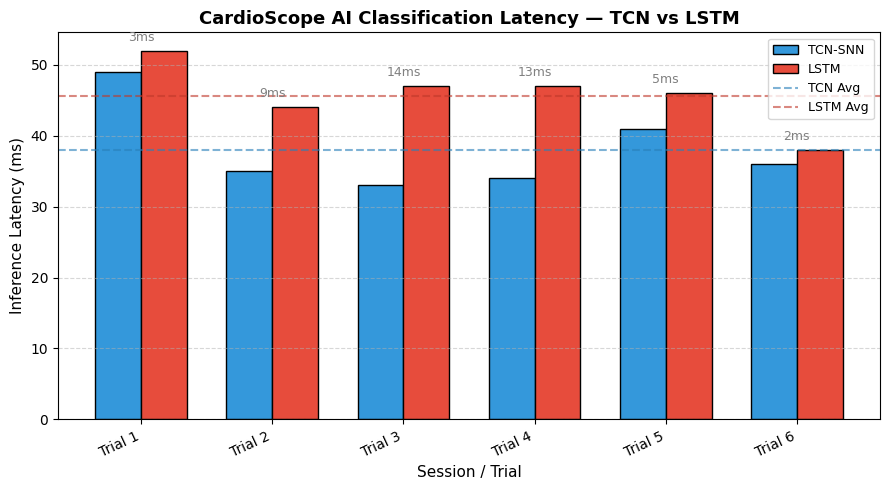

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# === CardioScope AI Classification Latency (ms) ===
sessions = [
    "Trial 1",
    "Trial 2",
    "Trial 3",
    "Trial 4",
    "Trial 5",
    "Trial 6"
]

# Latency per model (from logs)
tcn_ms = np.array([49, 35, 33, 34, 41, 36])
lstm_ms = np.array([52, 44, 47, 47, 46, 38])

# Difference (Δ)
diff_ms = np.abs(lstm_ms - tcn_ms)

# --- Bar chart setup ---
x = np.arange(len(sessions))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bar_tcn = ax.bar(x - width/2, tcn_ms, width, label="TCN-SNN", color="#3498DB", edgecolor="black")
bar_lstm = ax.bar(x + width/2, lstm_ms, width, label="LSTM", color="#E74C3C", edgecolor="black")

# --- Averages ---
tcn_avg = np.mean(tcn_ms)
lstm_avg = np.mean(lstm_ms)

# Plot dashed average lines (and keep handles for legend)
tcn_line = ax.axhline(tcn_avg, color="#2980B9", linestyle="--", alpha=0.6)
lstm_line = ax.axhline(lstm_avg, color="#C0392B", linestyle="--", alpha=0.6)

# --- Axis formatting ---
ax.set_ylabel("Inference Latency (ms)", fontsize=11)
ax.set_xlabel("Session / Trial", fontsize=11)
ax.set_title("CardioScope AI Classification Latency — TCN vs LSTM", fontsize=13, weight="bold")
ax.set_xticks(x)
ax.set_xticklabels(sessions, rotation=25, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.5)

# --- Annotate Δ difference ---
for i in range(len(x)):
    ax.text(x[i], max(tcn_ms[i], lstm_ms[i]) + 1,
            f"{diff_ms[i]}ms", ha="center", va="bottom", fontsize=9, color="gray")

# --- Custom legend including dashed lines ---
ax.legend(
    [bar_tcn, bar_lstm, tcn_line, lstm_line],
    ["TCN-SNN", "LSTM", "TCN Avg", "LSTM Avg"],
    loc="upper right",
    fontsize=9
)

# --- Styling ---
plt.tight_layout()
plt.savefig("CardioScope_TCNvsLSTM_Latency_WithAvg.png", dpi=400, bbox_inches="tight")
plt.show()

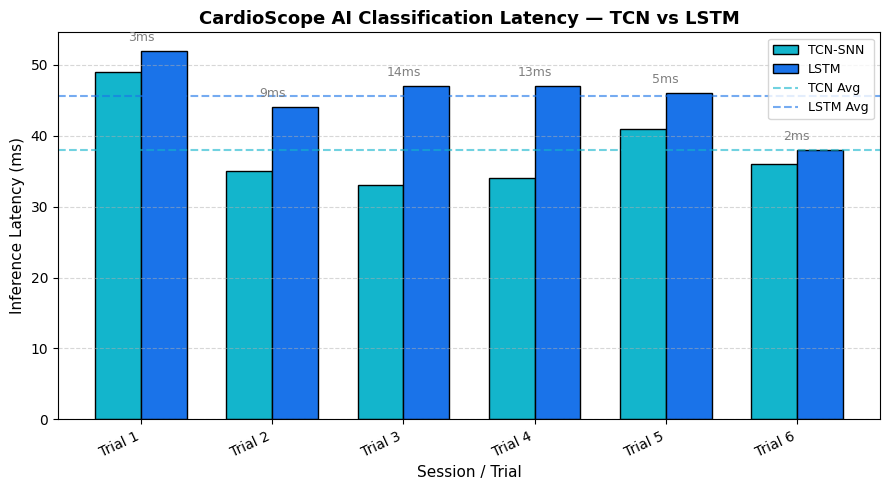

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# === CardioScope AI Classification Latency (ms) ===
sessions = ["Trial 1","Trial 2","Trial 3","Trial 4","Trial 5","Trial 6"]

# Latency per model (from logs)
tcn_ms = np.array([49, 35, 33, 34, 41, 36])
lstm_ms = np.array([52, 44, 47, 47, 46, 38])

# Difference (Δ)
diff_ms = np.abs(lstm_ms - tcn_ms)

# --- Bar chart setup ---
x = np.arange(len(sessions))
width = 0.35

# 🎨 Updated colors
tcn_color = "#13b5cc"     # CardioScope primary blue (Google Blue)
lstm_color = "#1a73e9"    # Cyan-blue

fig, ax = plt.subplots(figsize=(9, 5))
bar_tcn = ax.bar(x - width/2, tcn_ms, width, label="TCN-SNN",
                 color=tcn_color, edgecolor="black")
bar_lstm = ax.bar(x + width/2, lstm_ms, width, label="LSTM",
                  color=lstm_color, edgecolor="black")

# --- Averages ---
tcn_avg = np.mean(tcn_ms)
lstm_avg = np.mean(lstm_ms)

tcn_line = ax.axhline(tcn_avg, color=tcn_color, linestyle="--", alpha=0.6)
lstm_line = ax.axhline(lstm_avg, color=lstm_color, linestyle="--", alpha=0.6)

# --- Axis formatting ---
ax.set_ylabel("Inference Latency (ms)", fontsize=11)
ax.set_xlabel("Session / Trial", fontsize=11)
ax.set_title("CardioScope AI Classification Latency — TCN vs LSTM",
             fontsize=13, weight="bold")
ax.set_xticks(x)
ax.set_xticklabels(sessions, rotation=25, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.5)

# --- Annotate Δ difference ---
for i in range(len(x)):
    ax.text(x[i], max(tcn_ms[i], lstm_ms[i]) + 1,
            f"{diff_ms[i]}ms", ha="center", va="bottom",
            fontsize=9, color="gray")

# Legend
ax.legend([bar_tcn, bar_lstm, tcn_line, lstm_line],
          ["TCN-SNN", "LSTM", "TCN Avg", "LSTM Avg"],
          loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig("CardioScope_TCNvsLSTM_BlueTheme.png",
            dpi=400, bbox_inches="tight")
plt.show()
